# 本次模擬cmd log資訊

* 2026/05/23晚上（8,9點）開始模擬
* 只保留最後一個iteration(32486)的迭代資訊和AMReX finalize(如下)


# 確認哪些檔案為某apply voltage下的steady state

* 因為plotfile檔案太大所以以後要調大plot_int或乾脆只存steady state

## 使用者設定

In [1]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================
PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 100           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

## Utils

In [3]:
def get_plot_step(path: Path):
    """
    從 plt00000100 這種檔名取出 100
    """
    m = re.fullmatch(rf"{PLOT_PREFIX}(\d+)", path.name)
    if m is None:
        return None
    return int(m.group(1))


def find_plotfiles():
    """
    找出所有 plt######## 資料夾，並依 step 排序
    """
    plotfiles = []
    for p in PLOT_DIR.iterdir():
        if not p.is_dir():
            continue

        step = get_plot_step(p)
        if step is not None:
            plotfiles.append((step, p))

    plotfiles.sort(key=lambda x: x[0])
    return plotfiles


def find_phi_field(ds):
    """
    自動找 Phi field
    """
    field_list = list(ds.field_list) + list(ds.derived_field_list)

    for cand in PHI_FIELD_CANDIDATES:
        if cand in field_list:
            return cand

    raise RuntimeError(
        "找不到 Phi field。請先看 ds.field_list，然後手動修改 PHI_FIELD_CANDIDATES。\n"
        f"Available fields:\n{ds.field_list}"
    )


def read_top_phi(plotfile: Path):
    """
    讀取 top electrode / top boundary 附近的 Phi 平均值。

    這裡用 domain 最上層一個 cell-thickness 的 slab：
        z in [zmax - dz, zmax]
    取 Phi 平均。
    """
    ds = yt.load(str(plotfile))
    phi_field = find_phi_field(ds)

    zmin = ds.domain_left_edge[2].to_value()
    zmax = ds.domain_right_edge[2].to_value()
    dz = ds.index.get_smallest_dx().to_value()

    xcen = 0.5 * (ds.domain_left_edge[0] + ds.domain_right_edge[0])
    ycen = 0.5 * (ds.domain_left_edge[1] + ds.domain_right_edge[1])
    zcen = ds.domain_right_edge[2] - 0.5 * ds.quan(dz, "code_length")

    width_x = ds.domain_right_edge[0] - ds.domain_left_edge[0]
    width_y = ds.domain_right_edge[1] - ds.domain_left_edge[1]
    width_z = ds.quan(dz, "code_length")

    top_slab = ds.box(
        [
            ds.domain_left_edge[0],
            ds.domain_left_edge[1],
            ds.domain_right_edge[2] - ds.quan(dz, "code_length"),
        ],
        [
            ds.domain_right_edge[0],
            ds.domain_right_edge[1],
            ds.domain_right_edge[2],
        ],
    )

    phi_vals = top_slab[phi_field].to_value()

    return {
        "top_phi_mean": float(np.mean(phi_vals)),
        "top_phi_min": float(np.min(phi_vals)),
        "top_phi_max": float(np.max(phi_vals)),
        "zmax": float(zmax),
        "dz": float(dz),
        "phi_field": str(phi_field),
        "time": float(ds.current_time.to_value()),
    }

## Main

* FerroX預設每100個step(iteration)或steady state存一次plot_file。
* 我們假設達成steady state的step不是100倍數，經篩選剛好有20個檔案，這些檔案的top potential平均,最大,最小值也都落在指定apply voltage(-5->-4->...->5->4...->-4)附近，會有xy dependence是因為內部polarization有xy dependence，而且**top potential是最高cell中心的potential**不是邊界的。

In [4]:
plotfiles = find_plotfiles()

if not plotfiles:
    raise RuntimeError("找不到 plt######## plotfiles。請確認你在 plotfile 所在資料夾執行。")

# step 不是 plot_int 倍數者，通常是 steady_state_step 輸出的檔案
non_100x = [(step, p) for step, p in plotfiles if step % PLOT_INTERVAL != 0]

print(f"Total plotfiles found: {len(plotfiles)}")
print(f"Plotfiles with step not multiple of {PLOT_INTERVAL}: {len(non_100x)}")
print()

print("Non-interval plotfiles:")
for step, p in non_100x:
    print(f"  step = {step:8d}, file = {p.name}")

print()
print("Reading top Phi from non-interval plotfiles...")

rows = []
for idx, (step, p) in enumerate(non_100x):
    info = read_top_phi(p)
    rows.append({
        "index": idx,
        "plotfile": p.name,
        "step": step,
        "time": info["time"],
        "top_phi_mean": info["top_phi_mean"],
        "top_phi_min": info["top_phi_min"],
        "top_phi_max": info["top_phi_max"],
        "zmax": info["zmax"],
        "dz": info["dz"],
        "phi_field": info["phi_field"],
    })

    print(
        f"{idx:3d}  {p.name}  step={step:8d}  "
        f"top_phi_mean={info['top_phi_mean']:+.6e}  "
        f"min={info['top_phi_min']:+.6e}  max={info['top_phi_max']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv("steady_plot_top_phi.csv", index=False)

print()
print("Saved: steady_plot_top_phi.csv")

if len(non_100x) == 20:
    print("Count check: OK, found 20 non-interval plotfiles.")
else:
    print(f"Count check: expected 20 maybe, but found {len(non_100x)}.")

yt : [INFO     ] 2026-05-24 14:33:09,749 Parameters: current_time              = 3.160000000000004e-11
yt : [INFO     ] 2026-05-24 14:33:09,750 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 14:33:09,751 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 14:33:09,751 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Total plotfiles found: 345
Plotfiles with step not multiple of 100: 20

Non-interval plotfiles:
  step =      158, file = plt00000158
  step =      298, file = plt00000298
  step =      485, file = plt00000485
  step =      774, file = plt00000774
  step =    16816, file = plt00016816
  step =    19025, file = plt00019025
  step =    20242, file = plt00020242
  step =    20878, file = plt00020878
  step =    22340, file = plt00022340
  step =    24065, file = plt00024065
  step =    24420, file = plt00024420
  step =    24558, file = plt00024558
  step =    24741, file = plt00024741
  step =    25021, file = plt00025021
  step =    26519, file = plt00026519
  step =    28053, file = plt00028053
  step =    29294, file = plt00029294
  step =    29978, file = plt00029978
  step =    31392, file = plt00031392
  step =    32486, file = plt00032486

Reading top Phi from non-interval plotfiles...


yt : [INFO     ] 2026-05-24 14:33:10,022 Parameters: current_time              = 5.960000000000045e-11
yt : [INFO     ] 2026-05-24 14:33:10,023 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 14:33:10,024 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 14:33:10,024 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 14:33:10,149 Parameters: current_time              = 9.699999999999983e-11
yt : [INFO     ] 2026-05-24 14:33:10,150 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 14:33:10,151 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 14:33:10,152 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


  0  plt00000158  step=     158  top_phi_mean=-5.032496e+00  min=-5.032496e+00  max=-5.032496e+00
  1  plt00000298  step=     298  top_phi_mean=-4.032514e+00  min=-4.032514e+00  max=-4.032514e+00


yt : [INFO     ] 2026-05-24 14:33:10,269 Parameters: current_time              = 1.5480000000000137e-10
yt : [INFO     ] 2026-05-24 14:33:10,270 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 14:33:10,271 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 14:33:10,271 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 14:33:10,384 Parameters: current_time              = 3.3632000000006644e-09
yt : [INFO     ] 2026-05-24 14:33:10,385 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 14:33:10,385 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 14:33:10,386 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


...

 14  plt00026519  step=   26519  top_phi_mean=+1.017825e+00  min=+9.868841e-01  max=+1.046551e+00
 15  plt00028053  step=   28053  top_phi_mean=+1.550851e-02  min=-1.442576e-02  max=+4.543013e-02


yt : [INFO     ] 2026-05-24 14:33:12,176 Parameters: current_time              = 5.995600000001472e-09
yt : [INFO     ] 2026-05-24 14:33:12,176 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 14:33:12,177 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 14:33:12,178 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 14:33:12,293 Parameters: current_time              = 6.2784000000015586e-09
yt : [INFO     ] 2026-05-24 14:33:12,294 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 14:33:12,295 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 14:33:12,296 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


 16  plt00029294  step=   29294  top_phi_mean=-9.866616e-01  min=-1.015480e+00  max=-9.557931e-01
 17  plt00029978  step=   29978  top_phi_mean=-1.991296e+00  min=-2.017693e+00  max=-1.958301e+00


yt : [INFO     ] 2026-05-24 14:33:12,407 Parameters: current_time              = 6.497200000001626e-09
yt : [INFO     ] 2026-05-24 14:33:12,407 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 14:33:12,408 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 14:33:12,409 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


 18  plt00031392  step=   31392  top_phi_mean=-2.995895e+00  min=-3.019545e+00  max=-2.961004e+00
 19  plt00032486  step=   32486  top_phi_mean=-4.001992e+00  min=-4.022344e+00  max=-3.965598e+00

Saved: steady_plot_top_phi.csv
Count check: OK, found 20 non-interval plotfiles.


#  刪掉非steady state檔案
* 每個plotfile 34.8MB，Input_MFIS_t_8跑完後有345個共約佔12GB，記憶體只剩3.6GB左右所以要刪

## 確認要刪哪些檔案

In [6]:
from pathlib import Path
import re

PLOT_INTERVAL = 100
KEEP_INITIAL = True

plots = []
for p in Path("/home/kaiwi/FAM/FerroX/Exec").iterdir():
    if p.is_dir():
        m = re.fullmatch(r"plt(\d+)", p.name)
        if m:
            plots.append((int(m.group(1)), p))
plots.sort()

to_keep = []
to_delete = []

for step, p in plots:
    keep = False

    if KEEP_INITIAL and step == 0:
        keep = True

    # keep steady-like plotfiles
    if step % PLOT_INTERVAL != 0:
        keep = True

    if keep:
        to_keep.append((step, p))
    else:
        to_delete.append((step, p))

print("Keep:")
for s, p in to_keep:
    print(f"  {p.name}")

print()
print("Would delete:")
for s, p in to_delete:
    print(f"  {p.name}")

print()
print(f"keep={len(to_keep)}, delete={len(to_delete)}")

Keep:
  plt00000000
  plt00000158
  plt00000298
  plt00000485
  plt00000774
  plt00016816
  plt00019025
  plt00020242
  plt00020878
  plt00022340
  plt00024065
  plt00024420
  plt00024558
  plt00024741
  plt00025021
  plt00026519
  plt00028053
  plt00029294
  plt00029978
  plt00031392
  plt00032486

Would delete:
  plt00000100
  plt00000200
  plt00000300
  plt00000400
  plt00000500
  plt00000600
  plt00000700
  plt00000800
  plt00000900
  plt00001000
  plt00001100
  plt00001200
  plt00001300
  plt00001400
  plt00001500
  plt00001600
  plt00001700
  plt00001800
  plt00001900
  plt00002000
  plt00002100
  plt00002200
  plt00002300
  plt00002400
  plt00002500
  plt00002600
  plt00002700
  plt00002800
  plt00002900
  plt00003000
  plt00003100
  plt00003200
  plt00003300
  plt00003400
  plt00003500
  plt00003600
  plt00003700
  plt00003800
  plt00003900
  plt00004000
  plt00004100
  plt00004200
  plt00004300
  plt00004400
  plt00004500
  plt00004600
  plt00004700
  plt00004800
  plt00004900

## 刪掉指定檔案

In [10]:
from pathlib import Path
import re
import shutil

PLOT_INTERVAL = 100
KEEP_INITIAL = True
DRY_RUN = False  # 先 True，確認後改 False
cnt = 0

plots = []
for p in Path("/home/kaiwi/FAM/FerroX/Exec").iterdir():
    if p.is_dir():
        m = re.fullmatch(r"plt(\d+)", p.name)
        if m:
            plots.append((int(m.group(1)), p))
plots.sort()

for step, p in plots:
    keep = False

    if KEEP_INITIAL and step == 0:
        keep = True

    if step % PLOT_INTERVAL != 0:
        keep = True

    if not keep:
        print("Delete" if not DRY_RUN else "Would delete", p)
        cnt += 1
        if not DRY_RUN:
            shutil.rmtree(p)

print(f"\nTotal to delete: {cnt}")

Delete /home/kaiwi/FAM/FerroX/Exec/plt00000100
Delete /home/kaiwi/FAM/FerroX/Exec/plt00000200
Delete /home/kaiwi/FAM/FerroX/Exec/plt00000300
Delete /home/kaiwi/FAM/FerroX/Exec/plt00000400
Delete /home/kaiwi/FAM/FerroX/Exec/plt00000500
Delete /home/kaiwi/FAM/FerroX/Exec/plt00000600
Delete /home/kaiwi/FAM/FerroX/Exec/plt00000700
Delete /home/kaiwi/FAM/FerroX/Exec/plt00000800
Delete /home/kaiwi/FAM/FerroX/Exec/plt00000900
Delete /home/kaiwi/FAM/FerroX/Exec/plt00001000
Delete /home/kaiwi/FAM/FerroX/Exec/plt00001100
Delete /home/kaiwi/FAM/FerroX/Exec/plt00001200
Delete /home/kaiwi/FAM/FerroX/Exec/plt00001300
Delete /home/kaiwi/FAM/FerroX/Exec/plt00001400
Delete /home/kaiwi/FAM/FerroX/Exec/plt00001500
Delete /home/kaiwi/FAM/FerroX/Exec/plt00001600
Delete /home/kaiwi/FAM/FerroX/Exec/plt00001700
Delete /home/kaiwi/FAM/FerroX/Exec/plt00001800
Delete /home/kaiwi/FAM/FerroX/Exec/plt00001900
Delete /home/kaiwi/FAM/FerroX/Exec/plt00002000
Delete /home/kaiwi/FAM/FerroX/Exec/plt00002100
Delete /home/

# plot

In [13]:
from pathlib import Path
import yt

PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec") 
PLOTFILE = "plt0000000"  # 改成你想看的 plotfile

plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)


Available plotfiles:
   plt00000000
   plt00000158
   plt00000298
   plt00000485
   plt00000774
   plt00016816
   plt00019025
   plt00020242
   plt00020878
   plt00022340
   plt00024065
   plt00024420
   plt00024558
   plt00024741
   plt00025021
   plt00026519
   plt00028053
   plt00029294
   plt00029978
   plt00031392
   plt00032486


## 列出 plotfile 裡有哪些可以畫

- fddf
* frgr

In [17]:

ds = yt.load(PLOT_DIR/plot_names[0])  # 先隨便載入一個，看看裡面有哪些 field

print("Loaded:", plot_names[0])
print()
print("Current time:", ds.current_time)
print("Domain min coordinate(m) :", ds.domain_left_edge)
print("Domain max coordinate(m) :", ds.domain_right_edge)
print("Domain dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print()
print("field_list:")
for f in ds.field_list:
    print("  ", f)

print()#換行
print("derived_field_list containing boxlib fields:")
for f in ds.derived_field_list:
    if isinstance(f, tuple) and f[0] == "boxlib":
        print("  ", f)

yt : [INFO     ] 2026-05-24 17:04:56,097 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-05-24 17:04:56,097 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 17:04:56,098 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 17:04:56,098 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Loaded: plt00000000

Current time: 0.0 code_time
Domain min coordinate(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
Domain max coordinate(m) : [1.60e-08 1.60e-08 2.95e-08] code_length
Domain dimensions(xyz方向各切成幾格): [64 64 59]

field_list:
   ('boxlib', 'Ex')
   ('boxlib', 'Ey')
   ('boxlib', 'Ez')
   ('boxlib', 'Phi')
   ('boxlib', 'PhiDiff')
   ('boxlib', 'PoissonRHS')
   ('boxlib', 'Px')
   ('boxlib', 'Py')
   ('boxlib', 'Pz')
   ('boxlib', 'alpha')
   ('boxlib', 'beta')
   ('boxlib', 'charge')
   ('boxlib', 'electrons')
   ('boxlib', 'epsilon')
   ('boxlib', 'holes')
   ('boxlib', 'mask')
   ('boxlib', 'theta')
   ('boxlib', 'tphase')

derived_field_list containing boxlib fields:
   ('boxlib', 'Ex')
   ('boxlib', 'Ey')
   ('boxlib', 'Ez')
   ('boxlib', 'Phi')
   ('boxlib', 'PhiDiff')
   ('boxlib', 'PoissonRHS')
   ('boxlib', 'Px')
   ('boxlib', 'Py')
   ('boxlib', 'Pz')
   ('boxlib', 'alpha')
   ('boxlib', 'beta')
   ('boxlib', 'cell_volume')
   ('boxlib', 'charge')
   ('boxlib', '

yt : [INFO     ] 2026-05-24 18:32:10,490 Parameters: current_time              = 3.160000000000004e-11
yt : [INFO     ] 2026-05-24 18:32:10,491 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 18:32:10,492 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 18:32:10,492 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
E_array shape = (64, 64, 59)


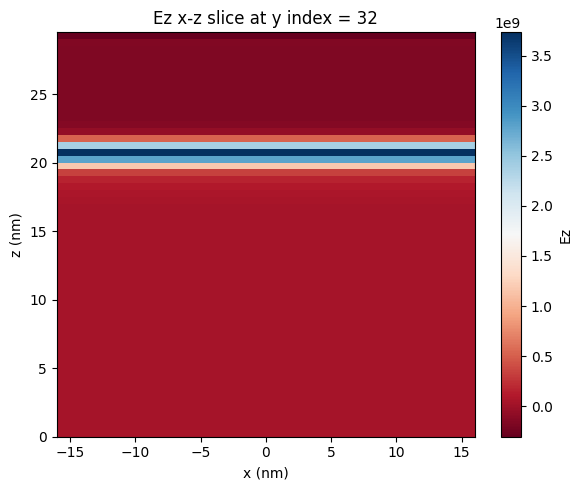

In [27]:
import yt
import numpy as np
import matplotlib.pyplot as plt

plotfile = PLOT_DIR/plot_names[1]
field = ("boxlib", "Ez")

ds = yt.load(plotfile)

print("field_list:")
for f in ds.field_list:
    print(f)

print("number of grids =", len(ds.index.grids))

g = ds.index.grids[0]
E_array = g[field].to_ndarray()

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ez")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ez x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

yt : [INFO     ] 2026-05-24 19:55:28,034 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-05-24 19:55:28,035 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:28,036 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:28,037 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


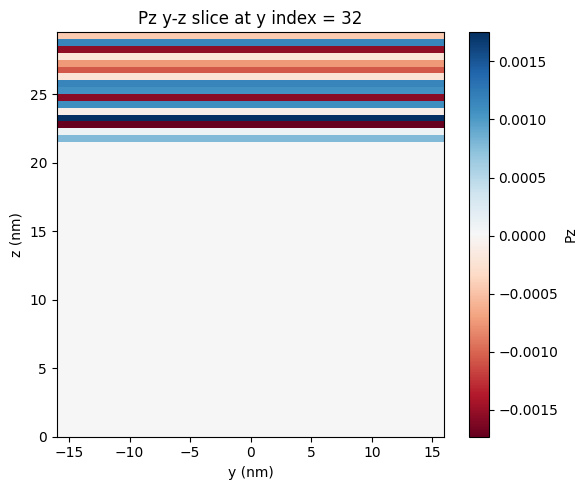

yt : [INFO     ] 2026-05-24 19:55:28,311 Parameters: current_time              = 3.160000000000004e-11
yt : [INFO     ] 2026-05-24 19:55:28,312 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:28,312 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:28,313 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


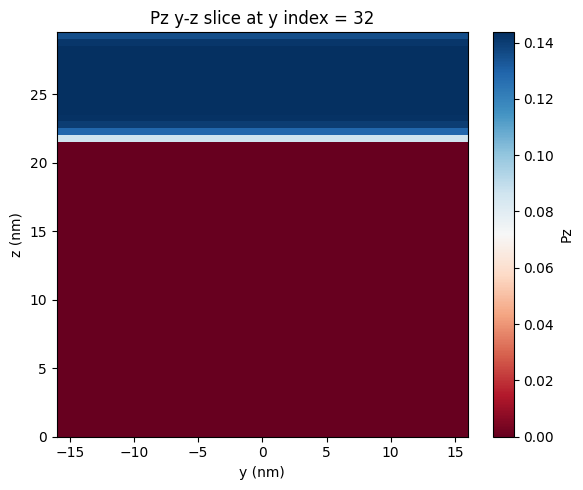

yt : [INFO     ] 2026-05-24 19:55:28,586 Parameters: current_time              = 5.960000000000045e-11
yt : [INFO     ] 2026-05-24 19:55:28,586 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:28,587 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:28,588 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


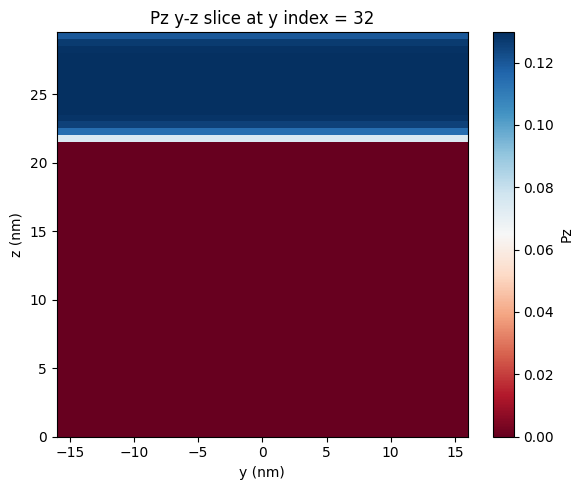

yt : [INFO     ] 2026-05-24 19:55:28,878 Parameters: current_time              = 9.699999999999983e-11
yt : [INFO     ] 2026-05-24 19:55:28,879 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:28,879 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:28,880 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


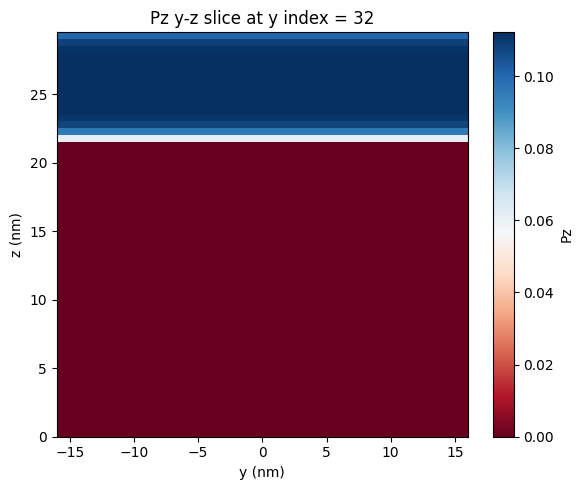

yt : [INFO     ] 2026-05-24 19:55:29,163 Parameters: current_time              = 1.5480000000000137e-10
yt : [INFO     ] 2026-05-24 19:55:29,164 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:29,165 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:29,166 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


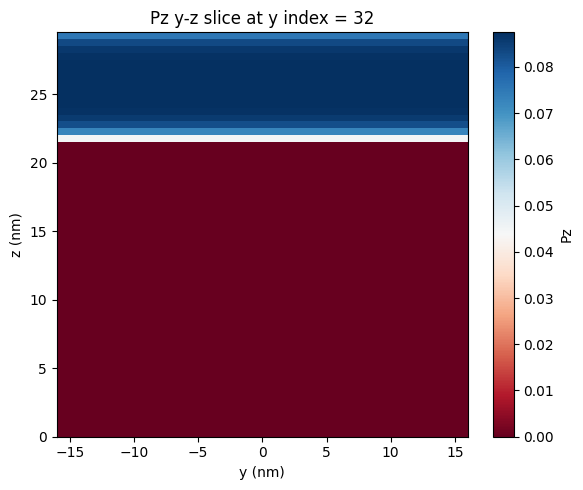

yt : [INFO     ] 2026-05-24 19:55:29,873 Parameters: current_time              = 3.3632000000006644e-09
yt : [INFO     ] 2026-05-24 19:55:29,875 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:29,876 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:29,876 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


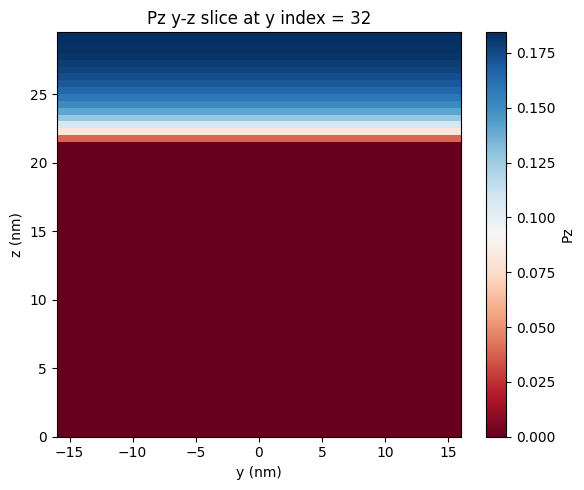

yt : [INFO     ] 2026-05-24 19:55:30,127 Parameters: current_time              = 3.8050000000008e-09
yt : [INFO     ] 2026-05-24 19:55:30,128 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:30,128 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:30,129 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


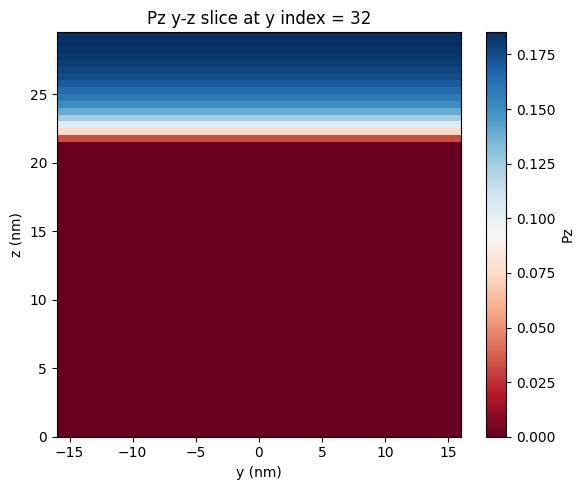

yt : [INFO     ] 2026-05-24 19:55:30,379 Parameters: current_time              = 4.0484000000008745e-09
yt : [INFO     ] 2026-05-24 19:55:30,380 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:30,381 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:30,382 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


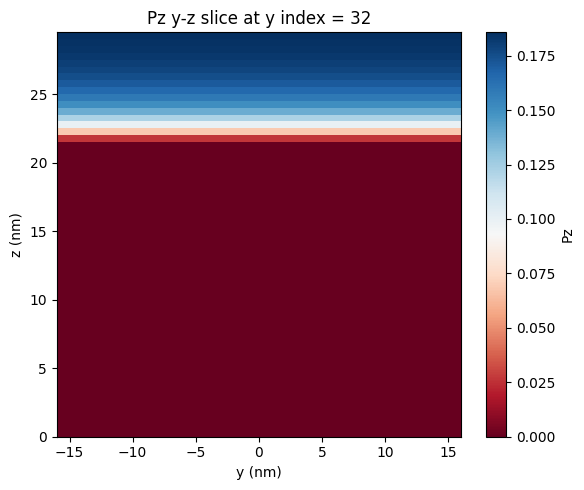

yt : [INFO     ] 2026-05-24 19:55:30,703 Parameters: current_time              = 4.1756000000009136e-09
yt : [INFO     ] 2026-05-24 19:55:30,704 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:30,705 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:30,706 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


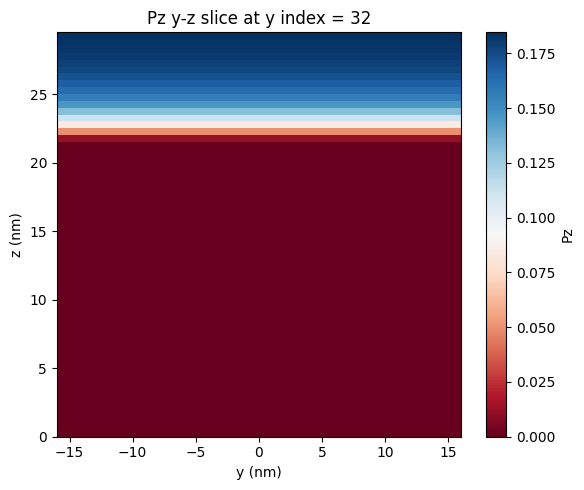

yt : [INFO     ] 2026-05-24 19:55:30,947 Parameters: current_time              = 4.468000000001003e-09
yt : [INFO     ] 2026-05-24 19:55:30,948 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:30,948 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:30,949 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


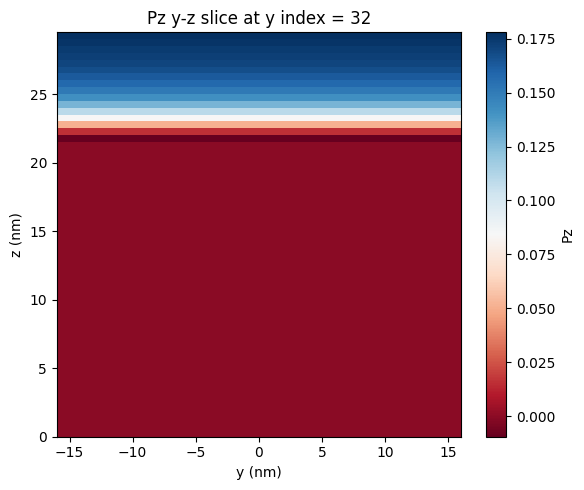

yt : [INFO     ] 2026-05-24 19:55:31,190 Parameters: current_time              = 4.813000000001109e-09
yt : [INFO     ] 2026-05-24 19:55:31,191 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:31,192 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:31,192 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


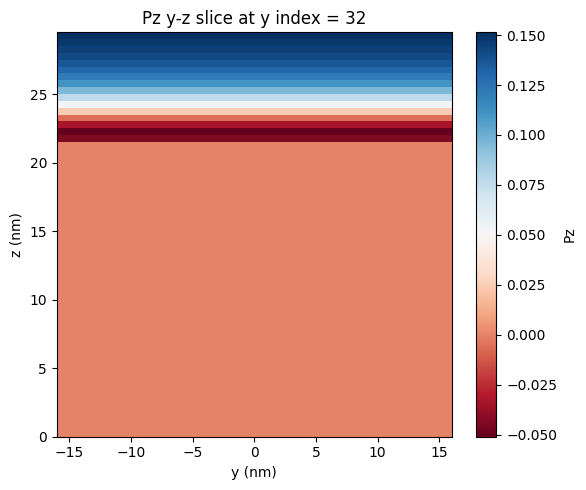

yt : [INFO     ] 2026-05-24 19:55:31,436 Parameters: current_time              = 4.884000000001131e-09
yt : [INFO     ] 2026-05-24 19:55:31,437 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:31,438 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:31,438 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


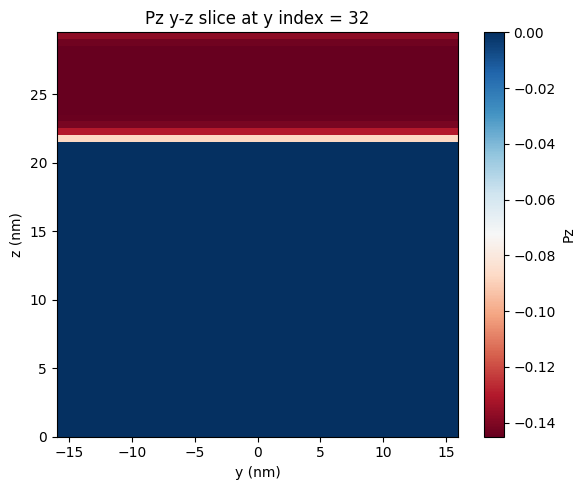

yt : [INFO     ] 2026-05-24 19:55:31,727 Parameters: current_time              = 4.911600000001139e-09
yt : [INFO     ] 2026-05-24 19:55:31,727 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:31,728 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:31,728 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


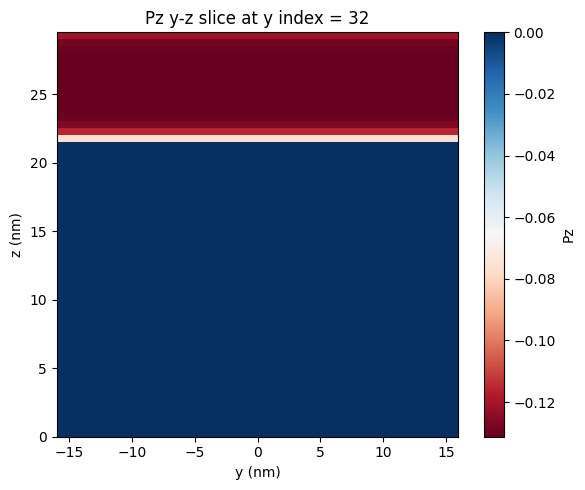

yt : [INFO     ] 2026-05-24 19:55:31,974 Parameters: current_time              = 4.9482000000011505e-09
yt : [INFO     ] 2026-05-24 19:55:31,975 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:31,976 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:31,977 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


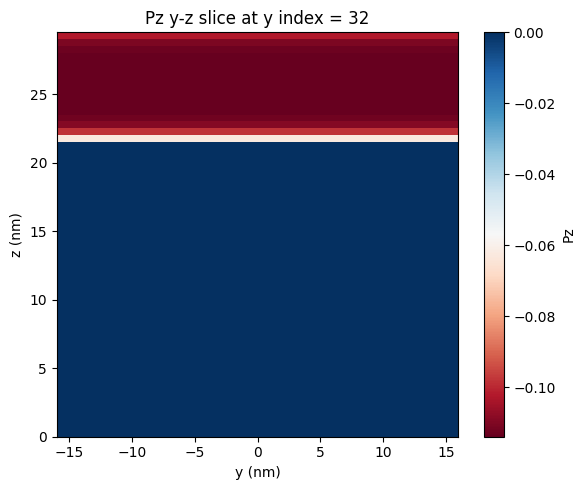

yt : [INFO     ] 2026-05-24 19:55:32,276 Parameters: current_time              = 5.004200000001168e-09
yt : [INFO     ] 2026-05-24 19:55:32,278 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:32,279 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:32,280 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


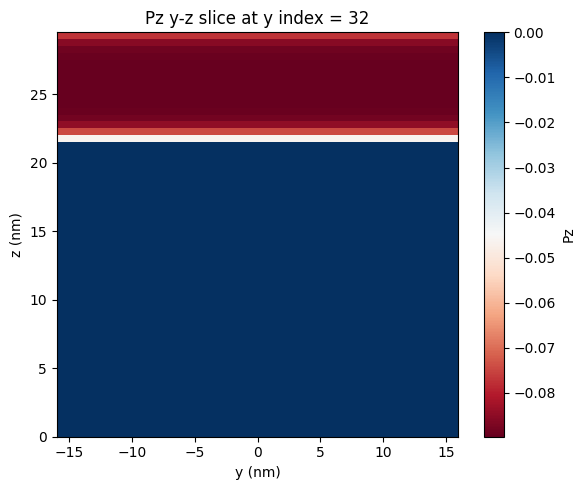

yt : [INFO     ] 2026-05-24 19:55:32,550 Parameters: current_time              = 5.30380000000126e-09
yt : [INFO     ] 2026-05-24 19:55:32,551 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:32,552 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:32,552 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


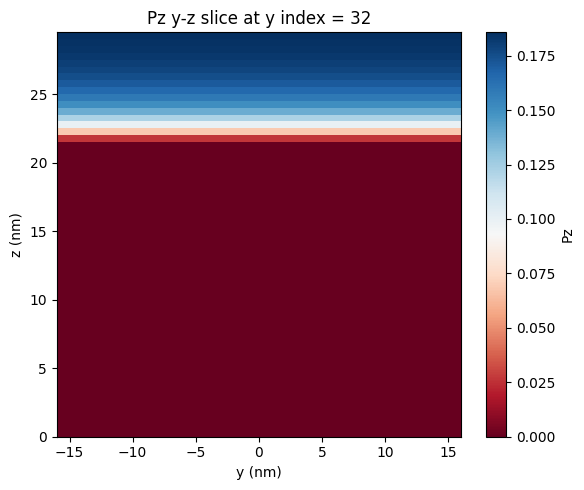

yt : [INFO     ] 2026-05-24 19:55:33,312 Parameters: current_time              = 5.610600000001354e-09
yt : [INFO     ] 2026-05-24 19:55:33,313 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:33,313 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:33,314 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


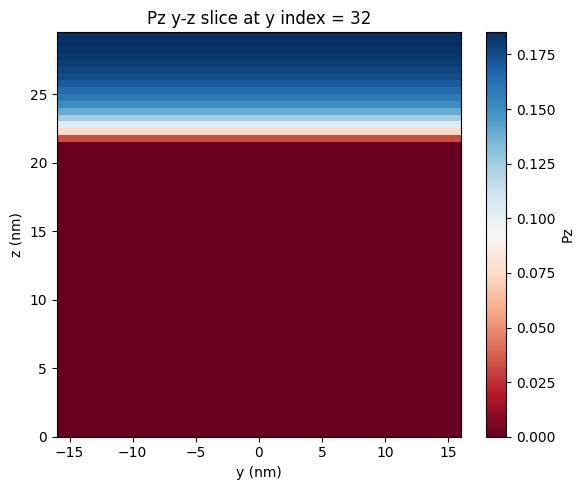

yt : [INFO     ] 2026-05-24 19:55:33,552 Parameters: current_time              = 5.85880000000143e-09
yt : [INFO     ] 2026-05-24 19:55:33,553 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:33,553 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:33,554 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


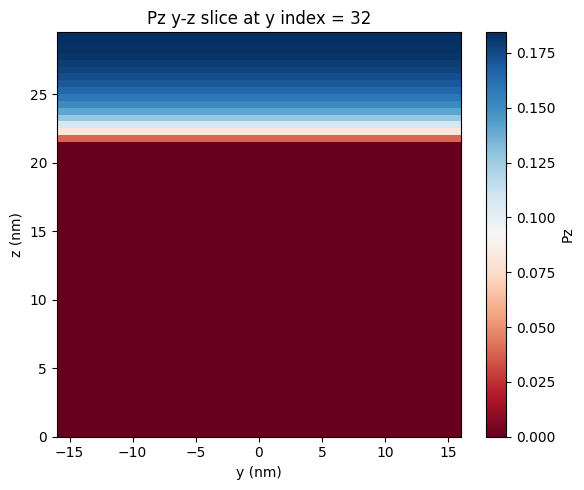

yt : [INFO     ] 2026-05-24 19:55:33,826 Parameters: current_time              = 5.995600000001472e-09
yt : [INFO     ] 2026-05-24 19:55:33,827 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:33,828 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:33,828 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


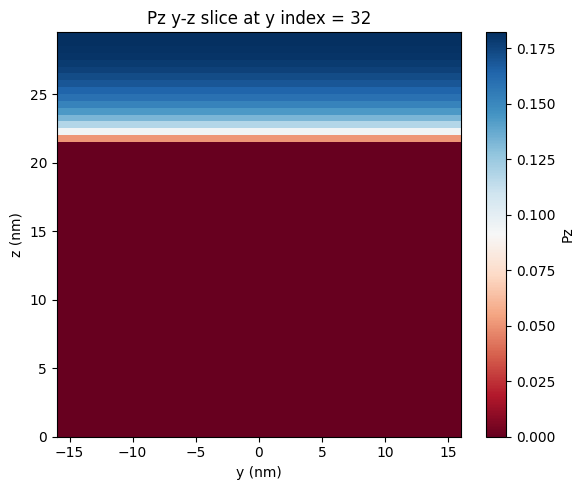

yt : [INFO     ] 2026-05-24 19:55:34,064 Parameters: current_time              = 6.2784000000015586e-09
yt : [INFO     ] 2026-05-24 19:55:34,065 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:34,065 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:34,066 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


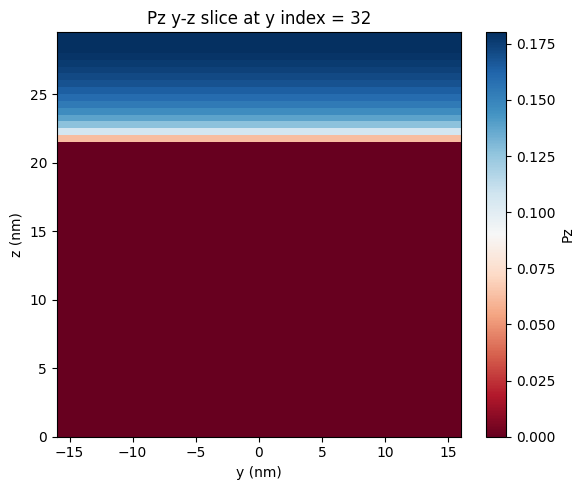

yt : [INFO     ] 2026-05-24 19:55:34,430 Parameters: current_time              = 6.497200000001626e-09
yt : [INFO     ] 2026-05-24 19:55:34,431 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:55:34,432 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:55:34,432 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


field_list:
('boxlib', 'Ex')
('boxlib', 'Ey')
('boxlib', 'Ez')
('boxlib', 'Phi')
('boxlib', 'PhiDiff')
('boxlib', 'PoissonRHS')
('boxlib', 'Px')
('boxlib', 'Py')
('boxlib', 'Pz')
('boxlib', 'alpha')
('boxlib', 'beta')
('boxlib', 'charge')
('boxlib', 'electrons')
('boxlib', 'epsilon')
('boxlib', 'holes')
('boxlib', 'mask')
('boxlib', 'theta')
('boxlib', 'tphase')
number of grids = 1
P_array shape = (64, 64, 59)


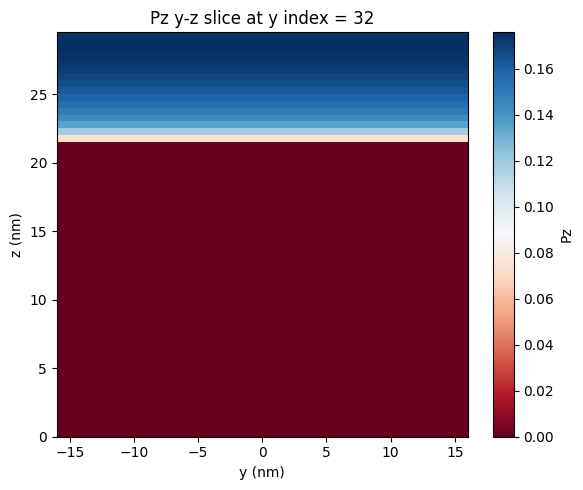

In [37]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i]
    field = ("boxlib", "Pz")

    ds = yt.load(plotfile)

    print("field_list:")
    for f in ds.field_list:
        print(f)

    print("number of grids =", len(ds.index.grids))

    g = ds.index.grids[0]
    P_array = g[field].to_ndarray()

    print("P_array shape =", P_array.shape)

    Nx, Ny, Nz = P_array.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    x0 = Nx // 2
    slice2d = P_array[x0, :, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        y_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Pz")
    plt.xlabel("y (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Pz y-z slice at y index = {x0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-05-24 19:24:22,907 Parameters: current_time              = 3.160000000000004e-11
yt : [INFO     ] 2026-05-24 19:24:22,908 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:24:22,909 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:24:22,909 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 19:24:23,052 Parameters: current_time              = 5.960000000000045e-11
yt : [INFO     ] 2026-05-24 19:24:23,053 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:24:23,054 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:24:23,055 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Plotfiles to draw:
  plt00000158
  plt00000298
  plt00000485
  plt00000774
  plt00016816
  plt00019025
  plt00020242
  plt00020878
  plt00022340
  plt00024065
  plt00024420
  plt00024558
  plt00024741
  plt00025021
  plt00026519
  plt00028053
  plt00029294
  plt00029978
  plt00031392
  plt00032486


yt : [INFO     ] 2026-05-24 19:24:23,183 Parameters: current_time              = 9.699999999999983e-11
yt : [INFO     ] 2026-05-24 19:24:23,184 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:24:23,184 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:24:23,185 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 19:24:23,300 Parameters: current_time              = 1.5480000000000137e-10
yt : [INFO     ] 2026-05-24 19:24:23,301 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:24:23,302 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:24:23,302 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 19:24:23,413 Parameters: current_time              = 3.3632000000006644e-09
yt : [INFO     ] 2026-05-24 19:24:23,414 Parameters: domain_dimen

Saved figure: Pz_FE_layer_stack.png


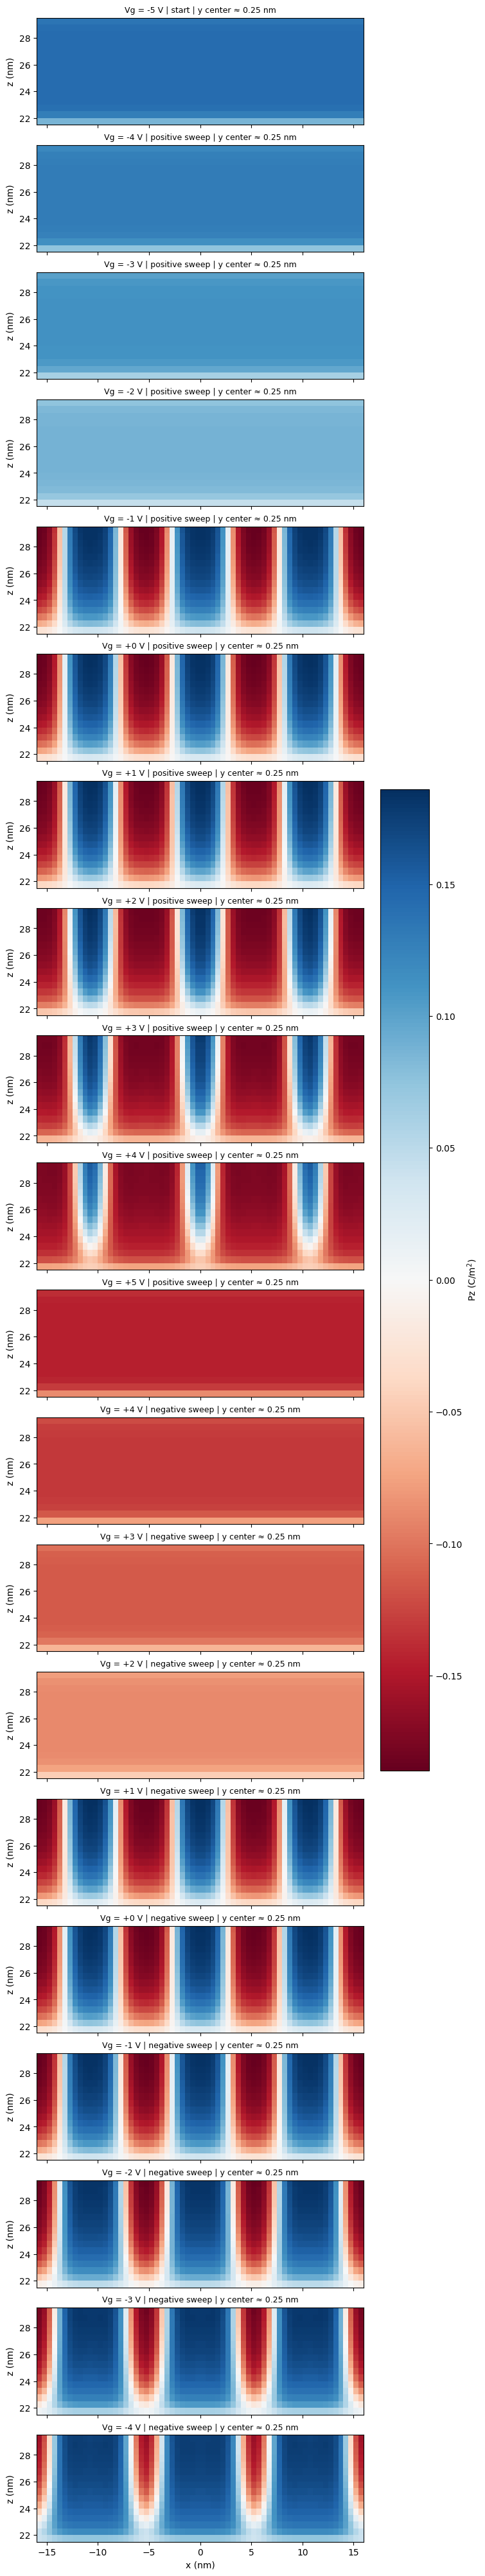

In [31]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# FE layer range, unit: nm
FE_Z_LO_NM = 21.5
FE_Z_HI_NM = 29.5

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可
USE_FE_X_RANGE = False
FE_X_LO_NM = -16.0
FE_X_HI_NM = 16.0

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = True

# 輸出圖片名稱
SAVE_FIG = True
OUT_FIG = "Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    g = ds.index.grids[0]

    P = to_numpy(g[P_FIELD])

    if PHI_FIELD in ds.field_list:
        Phi = to_numpy(g[PHI_FIELD])
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info


# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

# figure size
n = len(records)
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)

if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.0f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")

cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

yt : [INFO     ] 2026-05-24 19:34:29,431 Parameters: current_time              = 3.160000000000004e-11
yt : [INFO     ] 2026-05-24 19:34:29,432 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:34:29,432 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:34:29,433 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 19:34:29,547 Parameters: current_time              = 5.960000000000045e-11
yt : [INFO     ] 2026-05-24 19:34:29,548 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:34:29,549 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:34:29,549 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Plotfiles to read:
  plt00000158
  plt00000298
  plt00000485
  plt00000774
  plt00016816
  plt00019025
  plt00020242
  plt00020878
  plt00022340
  plt00024065
  plt00024420
  plt00024558
  plt00024741
  plt00025021
  plt00026519
  plt00028053
  plt00029294
  plt00029978
  plt00031392
  plt00032486


yt : [INFO     ] 2026-05-24 19:34:29,664 Parameters: current_time              = 9.699999999999983e-11
yt : [INFO     ] 2026-05-24 19:34:29,665 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:34:29,665 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:34:29,666 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 19:34:29,768 Parameters: current_time              = 1.5480000000000137e-10
yt : [INFO     ] 2026-05-24 19:34:29,769 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:34:29,769 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:34:29,770 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 19:34:29,871 Parameters: current_time              = 3.3632000000006644e-09
yt : [INFO     ] 2026-05-24 19:34:29,872 Parameters: domain_dimen


Read records:
plt00000158  step=158  Vtop=-5.0325 V  Vround=-5  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000298  step=298  Vtop=-4.0325 V  Vround=-4  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000485  step=485  Vtop=-3.0298 V  Vround=-3  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000774  step=774  Vtop=-2.0225 V  Vround=-2  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00016816  step=16816  Vtop=-0.9867 V  Vround=-1  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00019025  step=19025  Vtop=+0.0155 V  Vround=+0  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00020242  step=20242  Vtop=+1.0178 V  Vround=+1  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00020878  step=20878  Vtop=+2.0226 V  Vround=+2  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00022340  step=22340  Vtop=+3.0272 V  Vround=+3  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00024065  step=24065  Vtop=+4.0342 V  Vround=+4  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00024420  

/tmp/ipykernel_486959/2717279807.py:394: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.03, 0.94, 0.93])



Saved figure: Pz_FE_3D_2x11_sweep.png


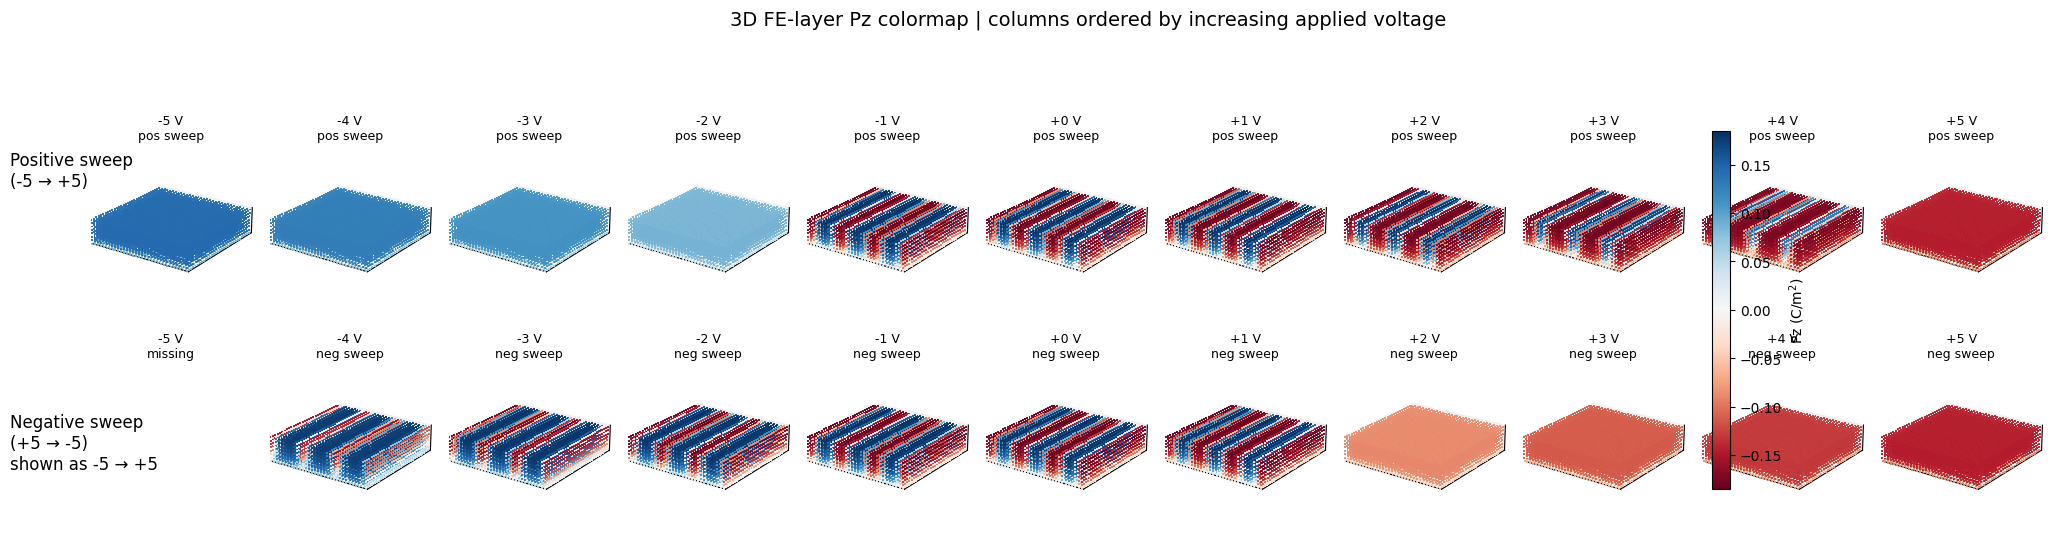

In [32]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ==========================
# User settings
# ==========================

PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# FE layer range, unit: nm
FE_Z_LO_NM = 21.5
FE_Z_HI_NM = 29.5

# 若 FE 只在部分 x/y 範圍，打開這裡
USE_FE_X_RANGE = False
FE_X_LO_NM = -16.0
FE_X_HI_NM = 16.0

USE_FE_Y_RANGE = False
FE_Y_LO_NM = -16.0
FE_Y_HI_NM = 16.0

# 要畫的電壓欄位：-5, -4, ..., 5
VOLTAGES = np.arange(-5, 6, 1)

# 用 top Phi 平均值四捨五入到整數電壓來分類
V_ROUND_DECIMALS = 0

# 3D 點太多會慢，STRIDE=2 表示 x/y/z 每 2 點取 1 點
# 若想更細可設 1；若很慢可設 3 或 4
STRIDE = 2

# 顏色是否以 0 對稱，畫 Pz 建議 True
SYMMETRIC_COLOR_SCALE = True

# 3D 視角
ELEV = 22
AZIM = -55

# 點大小
POINT_SIZE = 2

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 若你已經有 plot_names，就保留 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = False

SAVE_FIG = True
OUT_FIG = "Pz_FE_3D_2x11_sweep.png"


# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot_3d(plotfile):
    ds = yt.load(str(plotfile))
    g = ds.index.grids[0]

    P = to_numpy(g[P_FIELD])

    if PHI_FIELD in ds.field_list:
        Phi = to_numpy(g[PHI_FIELD])
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    # FE selection
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    # Apply selection
    P_fe = P[np.ix_(x_sel, y_sel, z_sel)]

    x_fe = x_nm[x_sel]
    y_fe = y_nm[y_sel]
    z_fe = z_nm[z_sel]

    # Downsample for 3D plotting
    P_ds = P_fe[::STRIDE, ::STRIDE, ::STRIDE]
    x_ds = x_fe[::STRIDE]
    y_ds = y_fe[::STRIDE]
    z_ds = z_fe[::STRIDE]

    X, Y, Z = np.meshgrid(x_ds, y_ds, z_ds, indexing="ij")

    # Estimate top voltage from top cell Phi
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    return {
        "P": P_ds,
        "X": X,
        "Y": Y,
        "Z": Z,
        "x_range": (float(np.min(x_fe)), float(np.max(x_fe))),
        "y_range": (float(np.min(y_fe)), float(np.max(y_fe))),
        "z_range": (float(np.min(z_fe)), float(np.max(z_fe))),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape_full": P.shape,
        "shape_fe": P_fe.shape,
        "shape_plot": P_ds.shape,
    }


def classify_sweep(records):
    """
    根據 records 原本的時間順序，用 Vtop 的變化判斷正掃/負掃。
    第一個點歸到 positive，因為通常是正掃起點。
    turning point 會同時加入 positive 與 negative，讓上下排都有 +5。
    """
    pos = []
    neg = []

    V = np.array([r["Vtop_mean"] for r in records], dtype=float)

    if len(records) == 0:
        return pos, neg

    pos.append(records[0])

    for i in range(1, len(records)):
        dV = V[i] - V[i - 1]

        if dV > 1e-8:
            pos.append(records[i])
        elif dV < -1e-8:
            # 如果剛從正掃轉負掃，把上一個 turning point 也放進 neg
            if len(neg) == 0:
                neg.append(records[i - 1])
            neg.append(records[i])
        else:
            # 同電壓重複時，不確定歸類；先放到目前方向
            if len(neg) == 0:
                pos.append(records[i])
            else:
                neg.append(records[i])

    return pos, neg


def pick_record_by_voltage(records, target_v):
    """
    從一組 records 中挑最接近 target_v 的那筆。
    """
    if len(records) == 0:
        return None

    V = np.array([r["Vround"] for r in records], dtype=float)
    idx = int(np.argmin(np.abs(V - target_v)))

    if np.abs(V[idx] - target_v) > 0.25:
        return None

    return records[idx]


def draw_3d_fe(ax, rec, norm, cmap):
    P = rec["P"]
    X = rec["X"]
    Y = rec["Y"]
    Z = rec["Z"]

    ax.scatter(
        X.ravel(),
        Y.ravel(),
        Z.ravel(),
        c=P.ravel(),
        cmap=cmap,
        norm=norm,
        s=POINT_SIZE,
        marker="s",
        linewidths=0,
        alpha=0.95,
    )

    ax.set_xlim(rec["x_range"])
    ax.set_ylim(rec["y_range"])
    ax.set_zlim(rec["z_range"])

    ax.view_init(elev=ELEV, azim=AZIM)

    # 22 張小圖，不要塞太多刻度
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.set_box_aspect((
        rec["x_range"][1] - rec["x_range"][0],
        rec["y_range"][1] - rec["y_range"][0],
        rec["z_range"][1] - rec["z_range"][0],
    ))


# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

print("Plotfiles to read:")
for n in plot_names_use:
    print(" ", n)

records = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot_3d(plotfile)

    Vround = np.round(info["Vtop_mean"], V_ROUND_DECIMALS)

    rec = {
        "name": name,
        "step": get_step_from_name(name),
        "Vround": float(Vround),
        **info,
    }

    records.append(rec)

print("\nRead records:")
for r in records:
    print(
        f"{r['name']}  step={r['step']}  "
        f"Vtop={r['Vtop_mean']:+.4f} V  Vround={r['Vround']:+.0f}  "
        f"shape_fe={r['shape_fe']}  shape_plot={r['shape_plot']}"
    )

# classify positive / negative sweep from time ordering
pos_records, neg_records = classify_sweep(records)

print("\nPositive sweep records:")
for r in pos_records:
    print(f"  V={r['Vround']:+.0f}  {r['name']}")

print("\nNegative sweep records:")
for r in neg_records:
    print(f"  V={r['Vround']:+.0f}  {r['name']}")

# Arrange columns left-to-right by increasing voltage: -5, -4, ..., 5
pos_grid = [pick_record_by_voltage(pos_records, v) for v in VOLTAGES]
neg_grid = [pick_record_by_voltage(neg_records, v) for v in VOLTAGES]

# shared color scale from all selected records
selected_records = [r for r in pos_grid + neg_grid if r is not None]
if len(selected_records) == 0:
    raise RuntimeError("No records selected. Check plot_names or voltage classification.")

all_p = np.concatenate([r["P"].ravel() for r in selected_records])

if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_p))
    vmin = -vmax
else:
    vmin = np.nanmin(all_p)
    vmax = np.nanmax(all_p)

cmap = "RdBu"
norm = Normalize(vmin=vmin, vmax=vmax)

# 2 x 11 figure
fig = plt.figure(figsize=(22, 6.2))

axes = np.empty((2, len(VOLTAGES)), dtype=object)

for row in range(2):
    for col in range(len(VOLTAGES)):
        axes[row, col] = fig.add_subplot(
            2,
            len(VOLTAGES),
            row * len(VOLTAGES) + col + 1,
            projection="3d"
        )

for col, Vtarget in enumerate(VOLTAGES):
    rec = pos_grid[col]
    ax = axes[0, col]

    if rec is not None:
        draw_3d_fe(ax, rec, norm, cmap)
        ax.set_title(f"{Vtarget:+.0f} V\npos sweep", fontsize=9)
    else:
        ax.set_title(f"{Vtarget:+.0f} V\nmissing", fontsize=9)
        ax.axis("off")

for col, Vtarget in enumerate(VOLTAGES):
    rec = neg_grid[col]
    ax = axes[1, col]

    if rec is not None:
        draw_3d_fe(ax, rec, norm, cmap)
        ax.set_title(f"{Vtarget:+.0f} V\nneg sweep", fontsize=9)
    else:
        ax.set_title(f"{Vtarget:+.0f} V\nmissing", fontsize=9)
        ax.axis("off")

# row labels
fig.text(0.01, 0.72, "Positive sweep\n(-5 → +5)", va="center", ha="left", fontsize=12)
fig.text(0.01, 0.28, "Negative sweep\n(+5 → -5)\nshown as -5 → +5", va="center", ha="left", fontsize=12)

# shared colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    shrink=0.75,
    pad=0.01,
    location="right"
)
cbar.set_label(r"Pz (C/m$^2$)")

fig.suptitle(
    "3D FE-layer Pz colormap | columns ordered by increasing applied voltage",
    fontsize=14
)

plt.tight_layout(rect=[0.04, 0.03, 0.94, 0.93])

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"\nSaved figure: {OUT_FIG}")

plt.show()

yt : [INFO     ] 2026-05-24 19:40:56,531 Parameters: current_time              = 4.468000000001003e-09
yt : [INFO     ] 2026-05-24 19:40:56,532 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:40:56,533 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:40:56,533 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


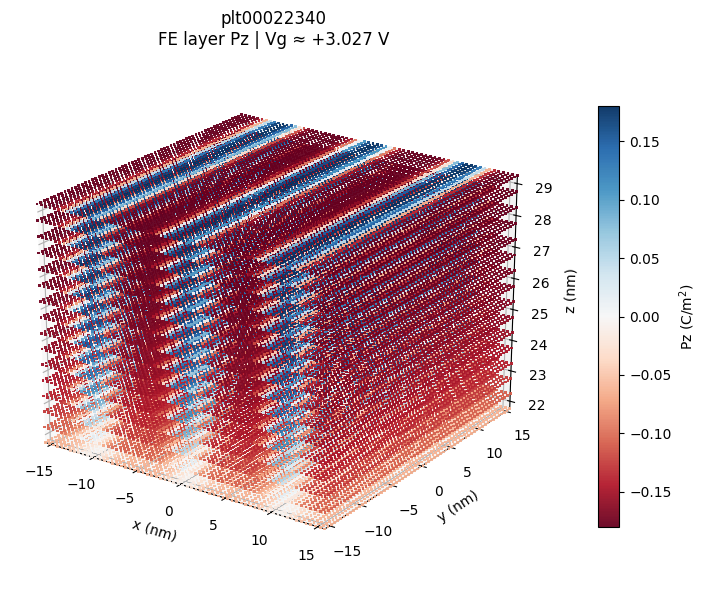

In [35]:
from pathlib import Path

import yt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


# ==========================
# User settings
# ==========================

PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")
PLOTFILE_NAME = "plt00022340"   # <<< 改成你要畫的那一張

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# FE layer range, unit: nm
FE_Z_LO_NM = 21.5
FE_Z_HI_NM = 29.5

# 如果 FE 只想取部分 x/y 範圍，可以改成 True
USE_FE_X_RANGE = False
FE_X_LO_NM = -16.0
FE_X_HI_NM = 16.0

USE_FE_Y_RANGE = False
FE_Y_LO_NM = -16.0
FE_Y_HI_NM = 16.0

# 下採樣，避免 3D 點太多
STRIDE = 1

# 3D 視角
ELEV = 22
AZIM = -55

# 點大小
POINT_SIZE = 4

# 色階是否以 0 對稱
SYMMETRIC_COLOR_SCALE = True


# ==========================
# Helper
# ==========================

def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


# ==========================
# Load data
# ==========================

plotfile = PLOT_DIR / PLOTFILE_NAME
ds = yt.load(str(plotfile))
g = ds.index.grids[0]

P = to_numpy(g[P_FIELD])

if PHI_FIELD in ds.field_list:
    Phi = to_numpy(g[PHI_FIELD])
else:
    Phi = None

Nx, Ny, Nz = P.shape

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dx = (hi - lo) / np.array([Nx, Ny, Nz])

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

# ==========================
# Select FE layer
# ==========================

z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

if USE_FE_X_RANGE:
    x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
else:
    x_sel = np.ones_like(x_nm, dtype=bool)

if USE_FE_Y_RANGE:
    y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
else:
    y_sel = np.ones_like(y_nm, dtype=bool)

P_fe = P[np.ix_(x_sel, y_sel, z_sel)]

x_fe = x_nm[x_sel]
y_fe = y_nm[y_sel]
z_fe = z_nm[z_sel]

# 下採樣
P_ds = P_fe[::STRIDE, ::STRIDE, ::STRIDE]
x_ds = x_fe[::STRIDE]
y_ds = y_fe[::STRIDE]
z_ds = z_fe[::STRIDE]

X, Y, Z = np.meshgrid(x_ds, y_ds, z_ds, indexing="ij")

# ==========================
# Voltage label
# ==========================

if Phi is not None:
    top_phi = Phi[:, :, -1]
    Vtop_mean = float(np.mean(top_phi))
    Vtop_min = float(np.min(top_phi))
    Vtop_max = float(np.max(top_phi))
else:
    Vtop_mean = np.nan
    Vtop_min = np.nan
    Vtop_max = np.nan

# ==========================
# Color scale
# ==========================

if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(P_ds))
    vmin = -vmax
else:
    vmin = np.nanmin(P_ds)
    vmax = np.nanmax(P_ds)

norm = Normalize(vmin=vmin, vmax=vmax)

# ==========================
# Plot
# ==========================

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    X.ravel(),
    Y.ravel(),
    Z.ravel(),
    c=P_ds.ravel(),
    cmap="RdBu",
    norm=norm,
    s=POINT_SIZE,
    marker="s",
    linewidths=0,
    alpha=0.95,
)

ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_zlabel("z (nm)")

ax.set_xlim(np.min(x_fe), np.max(x_fe))
ax.set_ylim(np.min(y_fe), np.max(y_fe))
ax.set_zlim(np.min(z_fe), np.max(z_fe))

ax.view_init(elev=ELEV, azim=AZIM)

ax.set_title(
    f"{PLOTFILE_NAME}\n"
    f"FE layer Pz | Vg ≈ {Vtop_mean:+.3f} V"
)

cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.08)
cbar.set_label(r"Pz (C/m$^2$)")

plt.tight_layout()
plt.show()

yt : [INFO     ] 2026-05-24 19:43:06,721 Parameters: current_time              = 4.468000000001003e-09
yt : [INFO     ] 2026-05-24 19:43:06,721 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 19:43:06,722 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 19:43:06,722 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


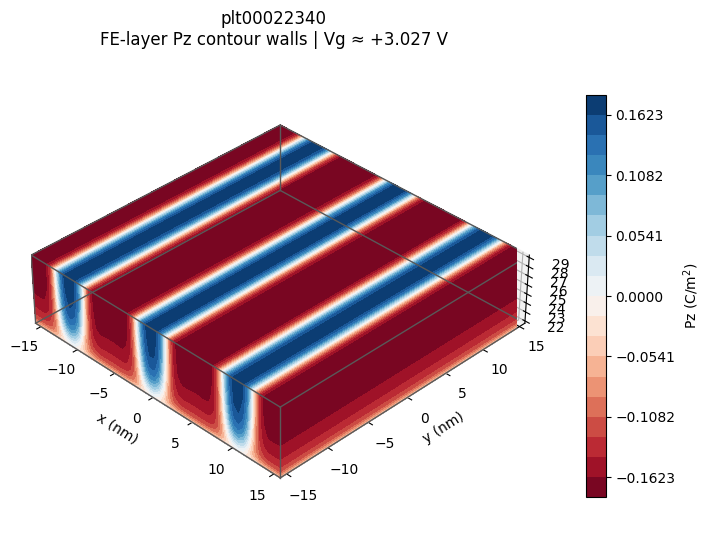

In [36]:
from pathlib import Path

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")
PLOTFILE_NAME = "plt00022340"   # 改成你要畫的 plotfile

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# FE layer range, unit: nm
FE_Z_LO_NM = 21.5
FE_Z_HI_NM = 29.5

# 如果 FE 只想取部分 x/y 範圍
USE_FE_X_RANGE = False
FE_X_LO_NM = -16.0
FE_X_HI_NM = 16.0

USE_FE_Y_RANGE = False
FE_Y_LO_NM = -16.0
FE_Y_HI_NM = 16.0

# contour levels
N_LEVELS = 21

# 視角
ELEV = 35
AZIM = -45

# 色階是否對稱於 0
SYMMETRIC_COLOR_SCALE = True


# ==========================
# Helper
# ==========================

def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


# ==========================
# Load data
# ==========================

plotfile = PLOT_DIR / PLOTFILE_NAME
ds = yt.load(str(plotfile))
g = ds.index.grids[0]

P = to_numpy(g[P_FIELD])

if PHI_FIELD in ds.field_list:
    Phi = to_numpy(g[PHI_FIELD])
else:
    Phi = None

Nx, Ny, Nz = P.shape

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dx = (hi - lo) / np.array([Nx, Ny, Nz])

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9


# ==========================
# Select FE layer
# ==========================

z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

if USE_FE_X_RANGE:
    x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
else:
    x_sel = np.ones_like(x_nm, dtype=bool)

if USE_FE_Y_RANGE:
    y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
else:
    y_sel = np.ones_like(y_nm, dtype=bool)

P_fe = P[np.ix_(x_sel, y_sel, z_sel)]

x_fe = x_nm[x_sel]
y_fe = y_nm[y_sel]
z_fe = z_nm[z_sel]

Nx_fe, Ny_fe, Nz_fe = P_fe.shape

# 選三個切面：
# xy plane at top FE surface
k_top = Nz_fe - 1

# xz plane at y center
j_mid = Ny_fe // 2

# yz plane at x max side
i_right = Nx_fe - 1

P_xy = P_fe[:, :, k_top]      # shape (Nx, Ny)
P_xz = P_fe[:, j_mid, :]      # shape (Nx, Nz)
P_yz = P_fe[i_right, :, :]    # shape (Ny, Nz)

# 建立 2D coordinates
X_xy, Y_xy = np.meshgrid(x_fe, y_fe, indexing="ij")
X_xz, Z_xz = np.meshgrid(x_fe, z_fe, indexing="ij")
Y_yz, Z_yz = np.meshgrid(y_fe, z_fe, indexing="ij")


# ==========================
# Voltage label
# ==========================

if Phi is not None:
    top_phi = Phi[:, :, -1]
    Vtop_mean = float(np.mean(top_phi))
else:
    Vtop_mean = np.nan


# ==========================
# Color scale
# ==========================

if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(P_fe))
    vmin = -vmax
else:
    vmin = np.nanmin(P_fe)
    vmax = np.nanmax(P_fe)

levels = np.linspace(vmin, vmax, N_LEVELS)

kw = dict(
    levels=levels,
    vmin=vmin,
    vmax=vmax,
    cmap="RdBu",
)


# ==========================
# Plot 3D contour walls
# ==========================

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

xmin, xmax = x_fe.min(), x_fe.max()
ymin, ymax = y_fe.min(), y_fe.max()
zmin, zmax = z_fe.min(), z_fe.max()

# 1. xy plane, placed at z = zmax
# contourf expects arrays with same shape.
# X_xy/Y_xy/P_xy are (Nx, Ny)
C1 = ax.contourf(
    X_xy,
    Y_xy,
    P_xy,
    zdir="z",
    offset=zmax,
    **kw
)

# 2. xz plane, placed at y = ymin
# Here x-axis is X_xz, vertical is Z_xz, color is P_xz
C2 = ax.contourf(
    X_xz,
    P_xz,
    Z_xz,
    zdir="y",
    offset=ymin,
    **kw
)

# 3. yz plane, placed at x = xmax
# Here horizontal axis is Y_yz, vertical is Z_yz, color is P_yz
C3 = ax.contourf(
    P_yz,
    Y_yz,
    Z_yz,
    zdir="x",
    offset=xmax,
    **kw
)

# Set axis limits
ax.set(
    xlim=[xmin, xmax],
    ylim=[ymin, ymax],
    zlim=[zmin, zmax],
)

# Draw box edges
edges_kw = dict(color="0.35", linewidth=1.0, zorder=1000)

# bottom rectangle
ax.plot([xmin, xmax], [ymin, ymin], [zmin, zmin], **edges_kw)
ax.plot([xmax, xmax], [ymin, ymax], [zmin, zmin], **edges_kw)
ax.plot([xmax, xmin], [ymax, ymax], [zmin, zmin], **edges_kw)
ax.plot([xmin, xmin], [ymax, ymin], [zmin, zmin], **edges_kw)

# top rectangle
ax.plot([xmin, xmax], [ymin, ymin], [zmax, zmax], **edges_kw)
ax.plot([xmax, xmax], [ymin, ymax], [zmax, zmax], **edges_kw)
ax.plot([xmax, xmin], [ymax, ymax], [zmax, zmax], **edges_kw)
ax.plot([xmin, xmin], [ymax, ymin], [zmax, zmax], **edges_kw)

# vertical edges
ax.plot([xmin, xmin], [ymin, ymin], [zmin, zmax], **edges_kw)
ax.plot([xmax, xmax], [ymin, ymin], [zmin, zmax], **edges_kw)
ax.plot([xmax, xmax], [ymax, ymax], [zmin, zmax], **edges_kw)
ax.plot([xmin, xmin], [ymax, ymax], [zmin, zmax], **edges_kw)

ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_zlabel("z (nm)")

ax.view_init(ELEV, AZIM)
ax.set_box_aspect((xmax - xmin, ymax - ymin, zmax - zmin))

ax.set_title(
    f"{PLOTFILE_NAME}\n"
    f"FE-layer Pz contour walls | Vg ≈ {Vtop_mean:+.3f} V"
)

cbar = fig.colorbar(C3, ax=ax, fraction=0.035, pad=0.12)
cbar.set_label(r"Pz (C/m$^2$)")

plt.tight_layout()
plt.show()

yt : [INFO     ] 2026-05-24 23:37:23,551 Parameters: current_time              = 3.160000000000004e-11
yt : [INFO     ] 2026-05-24 23:37:23,551 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 23:37:23,552 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 23:37:23,553 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 23:37:23,685 Parameters: current_time              = 5.960000000000045e-11
yt : [INFO     ] 2026-05-24 23:37:23,686 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 23:37:23,686 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 23:37:23,687 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 23:37:23,812 Parameters: current_time              = 9.699999999999983e-11
yt : [INFO     ] 2026-05-24 23:37:23,813 Parameters: domain_dimensi

plt00000158 | step=158 | Vg=-5.0325 V | <Pz>_FE=+1.381117e-01
plt00000298 | step=298 | Vg=-4.0325 V | <Pz>_FE=+1.240471e-01


yt : [INFO     ] 2026-05-24 23:37:23,948 Parameters: current_time              = 1.5480000000000137e-10
yt : [INFO     ] 2026-05-24 23:37:23,949 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 23:37:23,949 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 23:37:23,950 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 23:37:24,087 Parameters: current_time              = 3.3632000000006644e-09
yt : [INFO     ] 2026-05-24 23:37:24,088 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 23:37:24,089 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 23:37:24,090 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


plt00000485 | step=485 | Vg=-3.0298 V | <Pz>_FE=+1.064881e-01
plt00000774 | step=774 | Vg=-2.0225 V | <Pz>_FE=+8.222251e-02


yt : [INFO     ] 2026-05-24 23:37:24,219 Parameters: current_time              = 3.8050000000008e-09
yt : [INFO     ] 2026-05-24 23:37:24,220 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 23:37:24,221 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 23:37:24,221 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 23:37:24,349 Parameters: current_time              = 4.0484000000008745e-09
yt : [INFO     ] 2026-05-24 23:37:24,350 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 23:37:24,351 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 23:37:24,352 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


...

plt00026519 | step=26519 | Vg=+1.0178 V | <Pz>_FE=-1.242844e-02
plt00028053 | step=28053 | Vg=+0.0155 V | <Pz>_FE=-6.905385e-05


yt : [INFO     ] 2026-05-24 23:37:26,501 Parameters: current_time              = 5.995600000001472e-09
yt : [INFO     ] 2026-05-24 23:37:26,502 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 23:37:26,503 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 23:37:26,504 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-24 23:37:26,641 Parameters: current_time              = 6.2784000000015586e-09
yt : [INFO     ] 2026-05-24 23:37:26,642 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 23:37:26,642 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 23:37:26,643 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


plt00029294 | step=29294 | Vg=-0.9867 V | <Pz>_FE=+1.150174e-02
plt00029978 | step=29978 | Vg=-1.9913 V | <Pz>_FE=+3.651939e-02


yt : [INFO     ] 2026-05-24 23:37:26,774 Parameters: current_time              = 6.497200000001626e-09
yt : [INFO     ] 2026-05-24 23:37:26,775 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-24 23:37:26,776 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-24 23:37:26,777 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


plt00031392 | step=31392 | Vg=-2.9959 V | <Pz>_FE=+6.165733e-02
plt00032486 | step=32486 | Vg=-4.0020 V | <Pz>_FE=+8.986375e-02
Saved CSV: MFIS_PV_curve.csv
Saved figure: MFIS_PV_curve.png


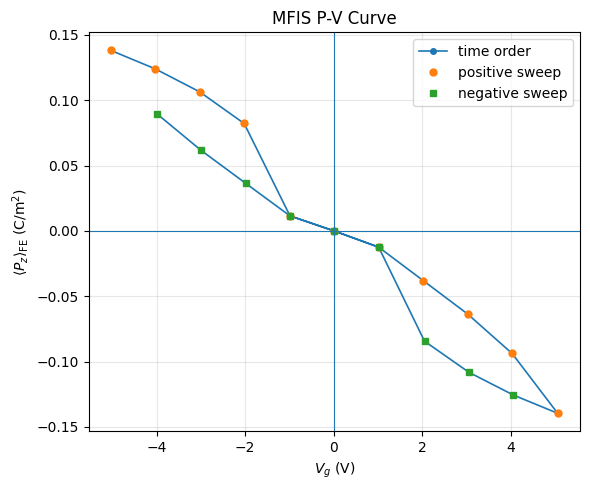

In [38]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# FE layer range, unit: nm
FE_Z_LO_NM = 21.5
FE_Z_HI_NM = 29.5

# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False
FE_X_LO_NM = -16.0
FE_X_HI_NM = 16.0

USE_FE_Y_RANGE = False
FE_Y_LO_NM = -16.0
FE_Y_HI_NM = 16.0

# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = False

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = "MFIS_PV_curve.csv"
OUT_FIG = "MFIS_PV_curve.png"


# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    g = ds.index.grids[0]

    Pz = to_numpy(g[P_FIELD])

    if PHI_FIELD not in ds.field_list:
        raise RuntimeError(f"{plotfile} does not contain {PHI_FIELD}")

    Phi = to_numpy(g[PHI_FIELD])

    Nx, Ny, Nz = Pz.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }


# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

rows = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()

direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)


# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

# time-order full loop
plt.plot(V, P, "-o", markersize=4, linewidth=1.2, label="time order")

# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], P[pos], "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], P[neg], "s", markersize=5, label="negative sweep")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (C/m$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()